# Avance 3. Baseline


## Librerías y Carga de Datos

In [1]:
USE_PLOTLY = True

### Librerías

In [2]:
import sys
sys.path.append('../../')

In [3]:
import pandas as pd
import numpy as np
from tabulate import tabulate
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, f_classif
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
!pip install holidays
from src.utils import helpers as func
!pip install prince
import prince as pr
import plotly.express as px

## Carga de Datos

In [4]:
path = '../../data/processed/df_entidades_acum.parquet'
df = func.load_data(path)

Cargando datos desde: ../../data/processed/df_entidades_acum.parquet
Dimensiones del DataFrame: (18272, 4)

Primeras filas del DataFrame:


,estado,fecha,valor,valor_acumulado
0,Aguascalientes,2014-01-06,1,1
1,Aguascalientes,2014-01-13,2,3
2,Aguascalientes,2014-01-20,1,4
3,Aguascalientes,2014-01-27,1,5
4,Aguascalientes,2014-02-03,2,7


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18272 entries, 0 to 18271
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   estado           18272 non-null  object        
 1   fecha            18272 non-null  datetime64[ns]
 2   valor            18272 non-null  int64         
 3   valor_acumulado  18272 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 571.1+ KB


## Análisis Visual de la Serie Temporal

In [6]:
# Gráfica de línea con seaborn
df_acumulado = func.get_cummulative_data(df, column='valor', group_by='fecha')
x= 'fecha'
y= 'valor_acumulado'
title = 'Serie de tiempo General acumulada (df_final)'

# Gráfica de línea con plotly / seaborn según selección del usuario
func.plot_timeseries(df_acumulado, x=x, y=y, title=title, plotly_engine=USE_PLOTLY)
df_acumulado.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 571 entries, 0 to 570
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   fecha            571 non-null    datetime64[ns]
 1   valor            571 non-null    int64         
 2   valor_acumulado  571 non-null    int64         
 3   semana           571 non-null    UInt32        
dtypes: UInt32(1), datetime64[ns](1), int64(2)
memory usage: 16.3 KB


In [7]:
# Gráfica de línea con seaborn
df_incrementos = df.groupby('fecha')['valor'].sum().reset_index()
x= 'fecha'
y= 'valor'
title = 'Serie de tiempo General por incrementos (df_final)'
# Gráfica de línea con plotly/seaborn según selección del usuario
func.plot_timeseries(df_incrementos, x=x, y=y, title=title, plotly_engine=USE_PLOTLY)
df_incrementos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 571 entries, 0 to 570
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   fecha   571 non-null    datetime64[ns]
 1   valor   571 non-null    int64         
 2   semana  571 non-null    UInt32        
dtypes: UInt32(1), datetime64[ns](1), int64(1)
memory usage: 11.8 KB


In [8]:
df_incrementos['valor_acumulado'] = df_incrementos['valor'].cumsum()
# Gráfica de línea con plotly / seaborn según selección del usuario
func.plot_timeseries(df_incrementos, x=x, y='valor_acumulado', title=title, plotly_engine=USE_PLOTLY)

## Ingeniería de Características

### Características Temporales

In [9]:
df = func.clean_column_names(df)
df["año"] = df["fecha"].dt.isocalendar().year
df["semana"] = df["fecha"].dt.isocalendar().week
df['mes'] = df['fecha'].dt.month
df['trimestre'] = df['fecha'].dt.quarter
df['semestre'] = df['fecha'].dt.month.apply(lambda m: 1 if m <= 6 else 2)
df['temporada'] = df['mes'].apply(func.asignar_temporada)
df.head()

,estado,fecha,valor,valor_acumulado,año,semana,mes,trimestre,semestre,temporada
0,Aguascalientes,2014-01-06,1,1,2014,2,1,1,1,Invierno
1,Aguascalientes,2014-01-13,2,3,2014,3,1,1,1,Invierno
2,Aguascalientes,2014-01-20,1,4,2014,4,1,1,1,Invierno
3,Aguascalientes,2014-01-27,1,5,2014,5,1,1,1,Invierno
4,Aguascalientes,2014-02-03,2,7,2014,6,2,1,1,Invierno


### Rezagos

In [10]:
sem_año = 52
lag_años = [1,2]
for año in lag_años:
    # lag año con respecto al anterior año indicado
    df[f"lag_{año}y"] = df.groupby(['fecha','estado'])["año"].shift(sem_año * año).fillna(0).astype(int)
    # lag del valor con respecto al año anterior indicado
    df[f"lag_v{año}y"] = df.groupby(['fecha','estado'])["valor"].shift(sem_año * año).fillna(0).astype(int)
    # lag del valor acumulado con respecto al año anterior indicado
    df[f"lag_va{año}y"] = df.groupby(['fecha','estado'])["valor_acumulado"].shift(sem_año * año).fillna(0).astype(int)
df

,estado,fecha,valor,valor_acumulado,año,semana,mes,trimestre,semestre,temporada,lag_1y,lag_v1y,lag_va1y,lag_2y,lag_v2y,lag_va2y
0,Aguascalientes,2014-01-06,1,1,2014,2,1,1,1,Invierno,0,0,0,0,0,0
1,Aguascalientes,2014-01-13,2,3,2014,3,1,1,1,Invierno,0,0,0,0,0,0
2,Aguascalientes,2014-01-20,1,4,2014,4,1,1,1,Invierno,0,0,0,0,0,0
3,Aguascalientes,2014-01-27,1,5,2014,5,1,1,1,Invierno,0,0,0,0,0,0
4,Aguascalientes,2014-02-03,2,7,2014,6,2,1,1,Invierno,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18267,Zacatecas,2024-11-25,56,18103,2024,48,11,4,2,Otoño,0,0,0,0,0,0
18268,Zacatecas,2024-12-02,56,18159,2024,49,12,4,2,Invierno,0,0,0,0,0,0
18269,Zacatecas,2024-12-09,47,18206,2024,50,12,4,2,Invierno,0,0,0,0,0,0
18270,Zacatecas,2024-12-16,42,18248,2024,51,12,4,2,Invierno,0,0,0,0,0,0


### Funciones cíclicas para meses

In [11]:
df["mes_sin"] = np.sin(2 * np.pi * df["mes"] / 12)
df["mes_cos"] = np.cos(2 * np.pi * df["mes"] / 12)


### Variables Exógenas

In [12]:
covid_start = pd.to_datetime('2020-03-01')
# covid_end = pd.to_datetime('2022-03-31')
covid_end = pd.to_datetime('2023-05-05')

df['periodo_covid'] = pd.cut(
    df['fecha'],
    bins=[pd.Timestamp.min, covid_start, 
          covid_end, pd.Timestamp.max],
    labels=['Pre-Covid', 'Covid', 'Post-Covid'],
    include_lowest=True
)

df['festivo'] = df.apply(func.encontrar_festivos_en_semana, axis=1)
df

,estado,fecha,valor,valor_acumulado,año,semana,mes,trimestre,semestre,temporada,lag_1y,lag_v1y,lag_va1y,lag_2y,lag_v2y,lag_va2y,mes_sin,mes_cos,periodo_covid,festivo
0,Aguascalientes,2014-01-06,1,1,2014,2,1,1,1,Invierno,0,0,0,0,0,0,5.000000e-01,0.866025,Pre-Covid,0
1,Aguascalientes,2014-01-13,2,3,2014,3,1,1,1,Invierno,0,0,0,0,0,0,5.000000e-01,0.866025,Pre-Covid,0
2,Aguascalientes,2014-01-20,1,4,2014,4,1,1,1,Invierno,0,0,0,0,0,0,5.000000e-01,0.866025,Pre-Covid,0
3,Aguascalientes,2014-01-27,1,5,2014,5,1,1,1,Invierno,0,0,0,0,0,0,5.000000e-01,0.866025,Pre-Covid,0
4,Aguascalientes,2014-02-03,2,7,2014,6,2,1,1,Invierno,0,0,0,0,0,0,8.660254e-01,0.500000,Pre-Covid,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18267,Zacatecas,2024-11-25,56,18103,2024,48,11,4,2,Otoño,0,0,0,0,0,0,-5.000000e-01,0.866025,Post-Covid,0
18268,Zacatecas,2024-12-02,56,18159,2024,49,12,4,2,Invierno,0,0,0,0,0,0,-2.449294e-16,1.000000,Post-Covid,0
18269,Zacatecas,2024-12-09,47,18206,2024,50,12,4,2,Invierno,0,0,0,0,0,0,-2.449294e-16,1.000000,Post-Covid,0
18270,Zacatecas,2024-12-16,42,18248,2024,51,12,4,2,Invierno,0,0,0,0,0,0,-2.449294e-16,1.000000,Post-Covid,0


## Codificación

In [13]:
df[['semana', 'mes', 'trimestre', 'semestre']] = df[['semana', 'mes', 'trimestre', 'semestre']].astype(object)

In [14]:
columnas_ohe = ['estado','semana','mes','trimestre','semestre','periodo_covid','temporada']
dummies = pd.get_dummies(df[columnas_ohe], drop_first=True)
# Remove columns that overlap before joining
# dummies = dummies.drop(columns=['semana', 'mes', 'trimestre', 'semestre'])
df = df.join(dummies)
df.drop(columns=columnas_ohe, inplace=True)

In [15]:
df = func.clean_column_names(df)
df.columns = df.columns.str.replace('_covid_', '_', n=1) # Simplifica nombres de columnas

In [16]:
df.head()

,fecha,valor,valor_acumulado,año,lag_1y,lag_v1y,lag_va1y,lag_2y,lag_v2y,lag_va2y,...,mes_12,trimestre_2,trimestre_3,trimestre_4,semestre_2,periodo_covid,periodo_post-covid,temporada_otoño,temporada_primavera,temporada_verano
0,2014-01-06,1,1,2014,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,2014-01-13,2,3,2014,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
2,2014-01-20,1,4,2014,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,2014-01-27,1,5,2014,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4,2014-02-03,2,7,2014,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False


## Exponential Smoothing

In [18]:
# índice temporal

df = df.sort_values('fecha')
df = df.set_index('fecha')

y = df['valor']

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluar_modelo(fit, y_true):
    y_pred = fit.fittedvalues
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

In [25]:
from statsmodels.tsa.holtwinters import Holt
holt_fit = Holt(y.astype(float), exponential=False).fit(optimized=True)
holt_mae, holt_rmse = evaluar_modelo(holt_fit, y)
print(f"HOLT  -> MAE={holt_mae:.2f}  RMSE={holt_rmse:.2f}")


c:\Users\naomi\anaconda3\envs\depression-analysis\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.



HOLT  -> MAE=45.39  RMSE=71.07


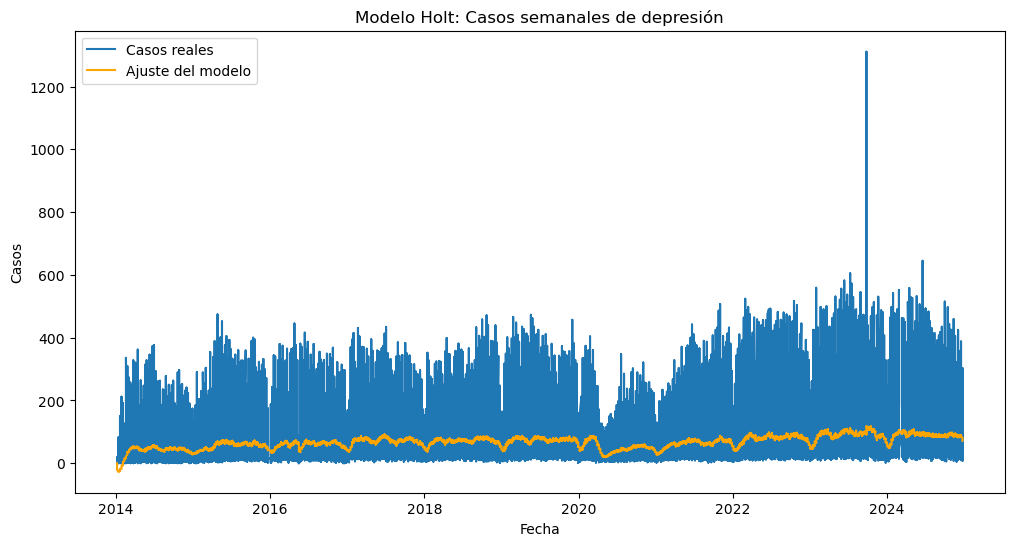

In [26]:
plt.figure(figsize=(12,6))
plt.plot(df['valor'], label='Casos reales')
plt.plot(holt_fit.fittedvalues, label='Ajuste del modelo', color='orange')
plt.title('Modelo Holt: Casos semanales de depresión')
plt.xlabel('Fecha')
plt.ylabel('Casos')
plt.legend()
plt.show()

# Notas

- [ ] Implementar df.diff()
  - Al utilizar el diff con el valor acumulado salía el valor, no probé con el box-cox previo al diff. <font color="red">Esta prueba la quité del archivo. </font>
- [ ] Implementar reduccion de caracteristicas
  - Volví a intentar MCA con las categóricas pero igual los componentes me salían con valores de varianza muy bajos < 0. <font color="red">Esta prueba la quité del archivo. </font> En el [enlace](https://maxhalford.github.io/prince/mca/) viene un ejemplo. Podría intentarse utilizar PCA después del One-hot.
- [x] Se añadieron lags para 1 y 2 años con respecto al: valor, valor acumulado, año. Para modificar o añadir se agregan o quita el multiplicador de semanas o años. Se podría aplicar PCA pero igual solo son 6 columnas.
- [ ] Se puede agregar lo de las ventanas que está en la [data](../../data/processed/df_acumulado.parquet) rolling_mean, rolling_std
